# Get Rain from MERGE

In [16]:
%load_ext autoreload
%autoreload 2

import json
import logging
from pathlib import Path

import geopandas as gpd
import pandas as pd
from mergedownloader.downloader import Downloader
from mergedownloader.file_downloader import ConnectionType, DownloadMode, FileDownloader
from mergedownloader.inpeparser import INPE_SERVER, InpeParsers, InpeTypes
from mergedownloader.utils import GISUtil


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Constants

In [17]:
BASIN = "RioBranco"
STATION = 13600002


path = Path(f"/data/CN3S/basins/{BASIN}")
assert path.exists(), f"Path {path} does not exist"

## Load Basin boundaries

<Axes: >

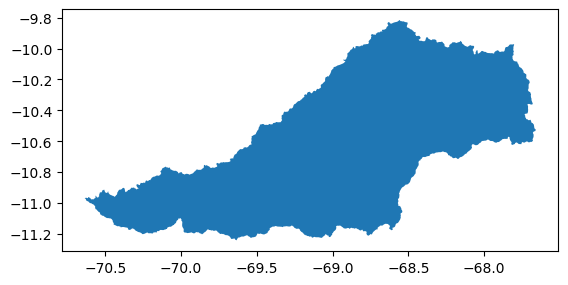

In [ ]:
basin = gpd.read_parquet(f"/data/CN3S/basins/{BASIN}/DA_Station_{STATION}.parquet")
basin.plot()


In [ ]:
# calculate the area in squared kilometers of basin (need to reproject to an equal-area projection first)
basin = basin.to_crs("epsg:32723")
basin["area_km2"] = basin.geometry.area / 1e6
print(f"Basin area: {basin['area_km2'].iloc[0]:.2f} km²")

Basin area: 27898.36 km²


In [ ]:
data = {
    "station": STATION,
    "area": basin["area_km2"].iloc[0],
}

In [ ]:
with (path / "metadata.json").open("w") as f:
    json.dump(data, f)

with (path / "metadata.json").open("r") as f:
    metadata = json.load(f)

metadata

{'station': 13600002, 'area': 27898.35854781605}

## Create Downloader

In [5]:
fd = FileDownloader(
    server=INPE_SERVER,
    connection_type=ConnectionType.HTTP,
    download_mode=DownloadMode.NO_UPDATE,
    log_level=logging.DEBUG,
)

downloader = Downloader(
    file_downloader=fd,
    local_folder="/data/CN3S/downloads",
    parsers=InpeParsers,
    log_level=logging.DEBUG,
)


Using wget through HTTP on: ftp.cptec.inpe.br


## Get MONTHLY MERGE Rain for Basin

In [8]:
cube = downloader.create_cube(
    "2000-01-01",
    "2026-05-01",
    InpeTypes.MONTHLY_ACCUM_YEARLY,
)


In [9]:
cube_clipped = GISUtil.cut_cube_by_geoms(cube, basin.geometry)

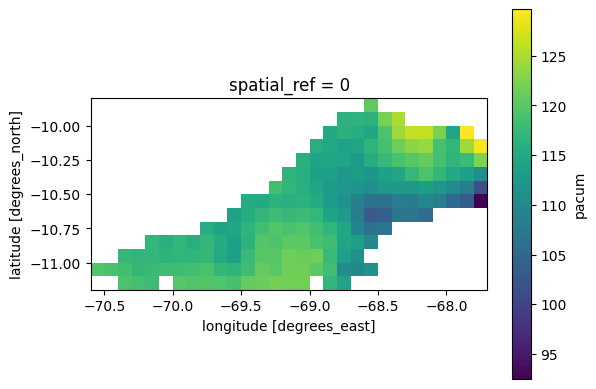

In [10]:
ax = basin.plot(color="none", edgecolor="red", linewidth=2, zorder=2)
cube_mean = cube_clipped.mean(dim="time")
cube_mean.plot(ax=ax, zorder=-1)

In [11]:
rain = cube_clipped.mean(dim=["latitude", "longitude"]).to_dataframe()
rain = rain.drop(columns=["spatial_ref"]).rename(columns={"pacum": "prec"})
rain

,prec
time,
2000-01-01 12:00:00,144.457254
2000-02-01 12:00:00,134.988990
2000-03-01 12:00:00,142.765868
2000-04-01 12:00:00,90.681995
2000-05-01 12:00:00,21.535622
...,...
2026-01-01 12:00:00,338.272668
2026-02-01 12:00:00,117.094883
2026-03-01 12:00:00,230.284326


In [12]:
rain.index = rain.index - pd.Timedelta(hours=12)

In [1]:
rain.to_parquet(f"/data/CN3S/basins/{BASIN}/Monthly_Prec_{STATION}.parquet")

NameError: name 'rain' is not defined

## Get monthly discharge

In [19]:
from utils.hydrology import Hydrology

hydro = Hydrology()

To sign in, use a web browser to open the page https://login.microsoft.com/device and enter the code EAP3LXX8K to authenticate.


In [20]:
daily_q = hydro.get_discharge(STATION, "vazao")
daily_q

,EstacaoCodigo,NivelConsistencia,Vazao
Data,,,
1967-08-08,13600002,2,15.20
1967-08-09,13600002,2,14.88
1967-08-10,13600002,2,14.27
1967-08-11,13600002,2,14.27
1967-08-12,13600002,2,14.27
...,...,...,...
2026-02-24,13600002,1,602.56
2026-02-25,13600002,1,630.80
2026-02-26,13600002,1,588.95


In [22]:
monthly_q = daily_q.resample("MS").mean()
monthly_q

,EstacaoCodigo,NivelConsistencia,Vazao
Data,,,
1967-08-01,13600002.0,2.0,12.697500
1967-09-01,13600002.0,2.0,13.331667
1967-10-01,13600002.0,2.0,17.889032
1967-11-01,13600002.0,2.0,49.125667
1967-12-01,13600002.0,2.0,178.139677
...,...,...,...
2025-10-01,13600002.0,1.0,53.106129
2025-11-01,13600002.0,1.0,149.632333
2025-12-01,13600002.0,1.0,800.373226


In [23]:
monthly_q.to_parquet(path / f"Monthly_Q_{STATION}.parquet")

In [24]:
STATION

13600002